# Z3 PRS validation scan ($\mu=1$, $N=512$, $L=100$, $\eta\le50$) --- analysis

Scan directory `scan_z3_prs_val/`: five runs with the **corrected** DWZ3 implementation
(two $\sqrt2$ bugs fixed in `fStar` and the vacuum-energy constant), using the
validated $\mu=1$ PRS recipe (prsWall from $t_0$, $H_0=1$).

**Coordinate:** unified $\beta_N = (1-R^2)/(1+R^2)$ where
$R=\sqrt{(1-\beta_N)/(1+\beta_N)}$ is the mid-wall radial suppression;
$\beta_N\in\{0.1,0.3,0.5,0.7,0.9\}$.

**Science goal:** confirm that every run (i) breaks the $\mathbb{Z}_3$ symmetry
[$\langle|\Phi|^2\rangle$ crosses $0.25$ from below], (ii) holds without melt
[$\langle|\Phi|^2\rangle\to 0.43$--$0.47$ and stays], and (iii) get a first look
at the wall-area $\mathcal{A}_1(\eta)$ scaling vs $\beta_N$, benchmarked against
the Z4 long scan.

**Only one wall type** in Z3 (a single topological charge step), so there is no
$\mathcal{A}_2$ (non-adjacent-wall) panel.

**Axis convention:** $x$-axis is program time $\eta$ (column 0 of every output file).
Fixed radiation background gives $a=1+\eta$, $2aH=2$ exactly, but we label $\eta$.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rc

USETEX = True
rc('text', usetex=USETEX)
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica'],
              'weight': 'bold', 'size': 16})

## Configuration

In [2]:
BASE = '/mt/user-batch/dpasari/scan_z3_prs_val/'

MU = 1.0

# BVP wall widths (dimensionless delta_bar, source: wall_width_box_calculator_Z3.ipynb)
D_ADJ = {0.1: 2.66, 0.3: 1.55, 0.5: 1.24, 0.7: 1.06, 0.9: 0.84}

BETAS = [0.1, 0.3, 0.5, 0.7, 0.9]

# Derived per-beta quantities (mu=1, h-vev=1 normalisation)
def derived(bN):
    R     = np.sqrt((1 - bN) / (1 + bN))
    kappa = 3.0 * (1 - R) / (1 + R)
    lam1  = 1.0 / R
    lam2  = np.sqrt(2.0) * (1 - R) / (3.0 * R)
    V0    = 0.5 + (1 - 4*R) / (12*R)
    return dict(R=R, kappa=kappa, lam1=lam1, lam2=lam2, V0=V0)

CONFIGS = [
    dict(name='b30p1', dirn='results_DWZ3_val_b30p1', beta_N=0.1,
         label=r'$\beta_N=0.1$', N=512, lSide=100.0),
    dict(name='b30p3', dirn='results_DWZ3_val_b30p3', beta_N=0.3,
         label=r'$\beta_N=0.3$', N=512, lSide=100.0),
    dict(name='b30p5', dirn='results_DWZ3_val_b30p5', beta_N=0.5,
         label=r'$\beta_N=0.5$', N=512, lSide=100.0),
    dict(name='b30p7', dirn='results_DWZ3_val_b30p7', beta_N=0.7,
         label=r'$\beta_N=0.7$', N=512, lSide=100.0),
    dict(name='b30p9', dirn='results_DWZ3_val_b30p9', beta_N=0.9,
         label=r'$\beta_N=0.9$', N=512, lSide=100.0),
]

_CMAP = plt.cm.winter
for c in CONFIGS:
    c['color'] = _CMAP((c['beta_N'] - 0.1) / 0.8)
    c['ls']    = 'solid'
    c['lw']    = 2.4
    c.update(derived(c['beta_N']))

def config_handles(items):
    return [Line2D([0], [0], color=d['color'], lw=d['lw'], ls=d['ls'],
                   label=d['label'])
            for d in items]

# Sizing / sanity table
print(f"{'card':10s} {'bN':>4s} {'R':>7s} {'kappa':>7s} {'lam1':>7s} {'lam2':>7s}"
      f" {'V0':>7s} {'dx':>6s} {'cpw':>9s} {'hor@50':>8s}")
print('-' * 80)
for c in CONFIGS:
    dx   = c['lSide'] / c['N']
    cpw  = D_ADJ[c['beta_N']] / (MU * dx)   # cells per wall
    hor  = MU * c['lSide'] / 51.0            # comoving horizons per side at eta=50
    print(f"{c['name']:10s} {c['beta_N']:>4.1f} {c['R']:>7.4f} {c['kappa']:>7.4f}"
          f" {c['lam1']:>7.4f} {c['lam2']:>7.4f} {c['V0']:>7.4f}"
          f" {dx:>6.4f} {cpw:>9.2f} {hor:>8.2f}")

card         bN       R   kappa    lam1    lam2      V0     dx       cpw   hor@50
--------------------------------------------------------------------------------
b30p1       0.1  0.9045  0.1504  1.1055  0.0498  0.2588 0.1953     13.62     1.96
b30p3       0.3  0.7338  0.4606  1.3628  0.1710  0.2802 0.1953      7.94     1.96
b30p5       0.5  0.5774  0.8038  1.7321  0.3451  0.3110 0.1953      6.35     1.96
b30p7       0.7  0.4201  1.2251  2.3805  0.6508  0.3650 0.1953      5.43     1.96
b30p9       0.9  0.2294  1.8804  4.3589  1.5834  0.5299 0.1953      4.30     1.96


## Loaders

In [3]:
def _safe_loadtxt(fpath):
    try:
        if not os.path.exists(fpath) or os.path.getsize(fpath) == 0:
            return None
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError, ValueError, StopIteration):
        return None
    if data.size == 0:
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    return data


def load_energies(path):
    # Z3: 10 columns -- eta, Ek1, Ek2, Eg1, Eg2, Ev1, Ev2, Ev3, E_tot, scal1
    data = _safe_loadtxt(os.path.join(path, 'average_energies.txt'))
    if data is None or data.shape[1] < 10:
        return None
    return {
        'eta':   data[:, 0], 'Ek_1': data[:, 1], 'Ek_2': data[:, 2],
        'Eg_1':  data[:, 3], 'Eg_2': data[:, 4], 'Ev_1': data[:, 5],
        'Ev_2':  data[:, 6], 'Ev_3': data[:, 7], 'E_tot': data[:, 8],
        'scal1': data[:, 9],
    }


def load_scalar(path, idx):
    # Z3 scalar files: 7 cols -- eta, phi, phi', phi2, phi'^2, sigma_phi, sigma_phi'
    data = _safe_loadtxt(os.path.join(path, f'average_scalar_{idx}.txt'))
    if data is None or data.shape[1] < 6:
        return None
    return {
        'eta':      data[:, 0],
        'phi':      data[:, 1],
        'phi_prime':data[:, 2],
        'phi2':     data[:, 3],
        'phi_prime2':data[:, 4],
        'rms_phi':  data[:, 5],   # = sqrt(<phi^2> - <phi>^2) = sigma
    }


def load_scale_factor(path):
    # Cols: eta, a, a', H  (col 3 is H, 0-indexed)
    data = _safe_loadtxt(os.path.join(path, 'average_scale_factor.txt'))
    if data is None or data.shape[1] < 4:
        return None
    return {'eta': data[:, 0], 'a': data[:, 1], 'aprime': data[:, 2],
            'H': data[:, 3]}

## Load all runs

Missing runs are silently skipped (`plot-if-ran` mode).

In [4]:
datasets = []
for c in CONFIGS:
    path = os.path.join(BASE, c['dirn'])
    en = load_energies(path)
    sf = load_scale_factor(path)
    s0 = load_scalar(path, 0)
    s1 = load_scalar(path, 1)
    ok = all(x is not None for x in [en, sf, s0, s1])
    last = f"{sf['eta'][-1]:.1f}" if sf is not None else '  --'
    print(f"{'OK' if ok else 'MISSING':8s} {c['name']:10s}  last eta={last}")
    d = dict(c)
    d.update(energies=en, scale_factor=sf, scalar_0=s0, scalar_1=s1)
    datasets.append(d)

ready = [d for d in datasets
         if all(d[k] is not None
                for k in ['energies', 'scale_factor', 'scalar_0', 'scalar_1'])]
print(f'\nReady: {len(ready)} / {len(datasets)}')

OK       b30p1       last eta=49.9
OK       b30p3       last eta=49.9
OK       b30p5       last eta=49.9
OK       b30p7       last eta=49.9
OK       b30p9       last eta=49.9

Ready: 5 / 5


## Plot helpers

In [5]:
def paper_ax(ax, xlabel=r'$\eta$', ylabel='', title=''):
    ax.set_xlabel(xlabel, fontsize=24)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=24)
    if title:
        ax.set_title(title, fontsize=20)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(axis='both', which='both', direction='in', labelsize=18, pad=6)
    ax.tick_params(which='major', length=9)
    ax.tick_params(which='minor', length=4)
    ax.minorticks_on()
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)


def phi2_radial(d):
    s0, s1 = d['scalar_0'], d['scalar_1']
    n = min(len(s0['eta']), len(s1['eta']))
    return s0['eta'][:n], (s0['phi2'][:n] + s1['phi2'][:n]) / 2.0


def area_param_A1(d):
    # A1 = scal1 / (2 a H); here 2aH = 2 exactly, so A1 = scal1/2
    en, sf = d['energies'], d['scale_factor']
    a_arr = np.interp(en['eta'], sf['eta'], sf['a'])
    H_arr = np.interp(en['eta'], sf['eta'], sf['H'])
    with np.errstate(divide='ignore', invalid='ignore'):
        A = en['scal1'] / (2.0 * a_arr * H_arr)
    return en['eta'], A


def breaking_onset_eta(d):
    # First eta > 1 where <|Phi|^2> crosses 0.25 from below
    eta, p2 = phi2_radial(d)
    mask = (eta > 1.0) & (p2 > 0.25)
    return float(eta[mask][0]) if mask.any() else None


def local_logslope(x, y, nbin=60):
    # d ln y / d ln x on coarse log-spaced bins (noise-robust)
    m = (x > 0) & (y > 0) & np.isfinite(y)
    if m.sum() < 10:
        return np.array([]), np.array([])
    lx, ly = np.log(x[m]), np.log(y[m])
    edges = np.linspace(lx[0], lx[-1], nbin + 1)
    idx = np.digitize(lx, edges)
    bx, by = [], []
    for i in range(1, nbin + 1):
        sel = idx == i
        if sel.sum() > 0:
            bx.append(lx[sel].mean())
            by.append(ly[sel].mean())
    bx, by = np.array(bx), np.array(by)
    if len(bx) < 4:
        return np.array([]), np.array([])
    return np.exp(0.5 * (bx[1:] + bx[:-1])), np.diff(by) / np.diff(bx)


def add_legend(ax, items, **kw):
    kw.setdefault('fontsize', 13)
    kw.setdefault('frameon', False)
    kw.setdefault('loc', 'upper left')
    kw.setdefault('bbox_to_anchor', (1.02, 1.0))
    kw.setdefault('borderaxespad', 0)
    ax.legend(handles=config_handles(items), **kw)

## 1. Health: radial diagnostic $\langle|\Phi|^2\rangle$ and mean-field drift

**Left panel:** $\langle|\Phi|^2\rangle = (\langle h^2\rangle + \langle a^2\rangle)/2$.
Guide at $0.5$ = vacuum value; dashed guide at $0.25$ = **breaking marker** (see note below).

**Right panel:** $|\langle\Phi\rangle| = \sqrt{\langle h\rangle^2+\langle a\rangle^2}$ ---
growth toward $\mathcal{O}(1)$ signals finite-volume domain depletion (few domains left).

**Breaking marker:** $\langle|\Phi|^2\rangle > 0.25$ is the reliable criterion.
Do **not** use $E_{V_1}<0$: $V_0$ is $\beta_N$-dependent and for $\beta_N=0.9$
we have $V_0=0.530>0.5$, so $E_{V_1}$ remains positive even in the broken vacuum.

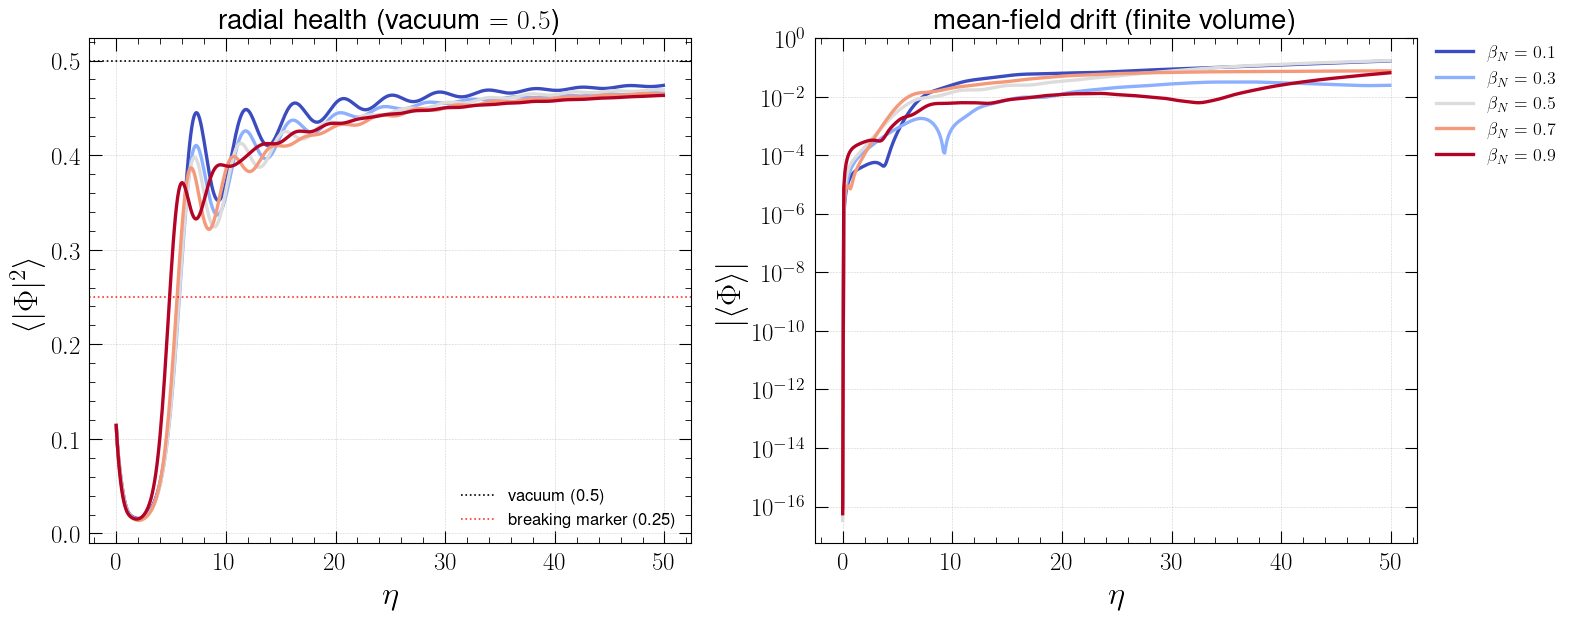

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for d in ready:
    eta, p2 = phi2_radial(d)
    axes[0].plot(eta, p2, color=d['color'], ls=d['ls'], lw=d['lw'])
    s0, s1 = d['scalar_0'], d['scalar_1']
    drift = np.sqrt(s0['phi']**2
                    + np.interp(s0['eta'], s1['eta'], s1['phi'])**2)
    axes[1].plot(s0['eta'], drift, color=d['color'], ls=d['ls'], lw=d['lw'])

axes[0].axhline(0.5,  color='k',  ls=':', lw=1.2, label='vacuum (0.5)')
axes[0].axhline(0.25, color='r',  ls=':', lw=1.2, alpha=0.8, label='breaking marker (0.25)')
axes[0].legend(fontsize=12, frameon=False)
axes[1].set_yscale('log')

paper_ax(axes[0], ylabel=r'$\langle|\Phi|^2\rangle$',
         title=r'radial health (vacuum $= 0.5$)')
paper_ax(axes[1], ylabel=r'$|\langle\Phi\rangle|$',
         title=r'mean-field drift (finite volume)')
add_legend(axes[1], ready)
plt.tight_layout()
plt.show()

## 2. Potential energies $E_{V_1}$, $E_{V_2}$, $E_{V_3}$

$E_{V_1} = -\mu^2\langle|\Phi|^2\rangle + V_0$ where $V_0$ is a $\beta_N$-dependent
vacuum-energy offset.  The **vacuum value** of $E_{V_1}$ is $V_0 - 0.5$ (since
$\langle|\Phi|^2\rangle\to 0.5$ in the broken phase), shown as a dashed horizontal per run.

For $\beta_N=0.9$, $V_0=0.530>0.5$ so the vacuum $E_{V_1}>0$ --- $E_{V_1}$ staying
positive does **not** mean the symmetry is unbroken; use the $\langle|\Phi|^2\rangle>0.25$
criterion instead.

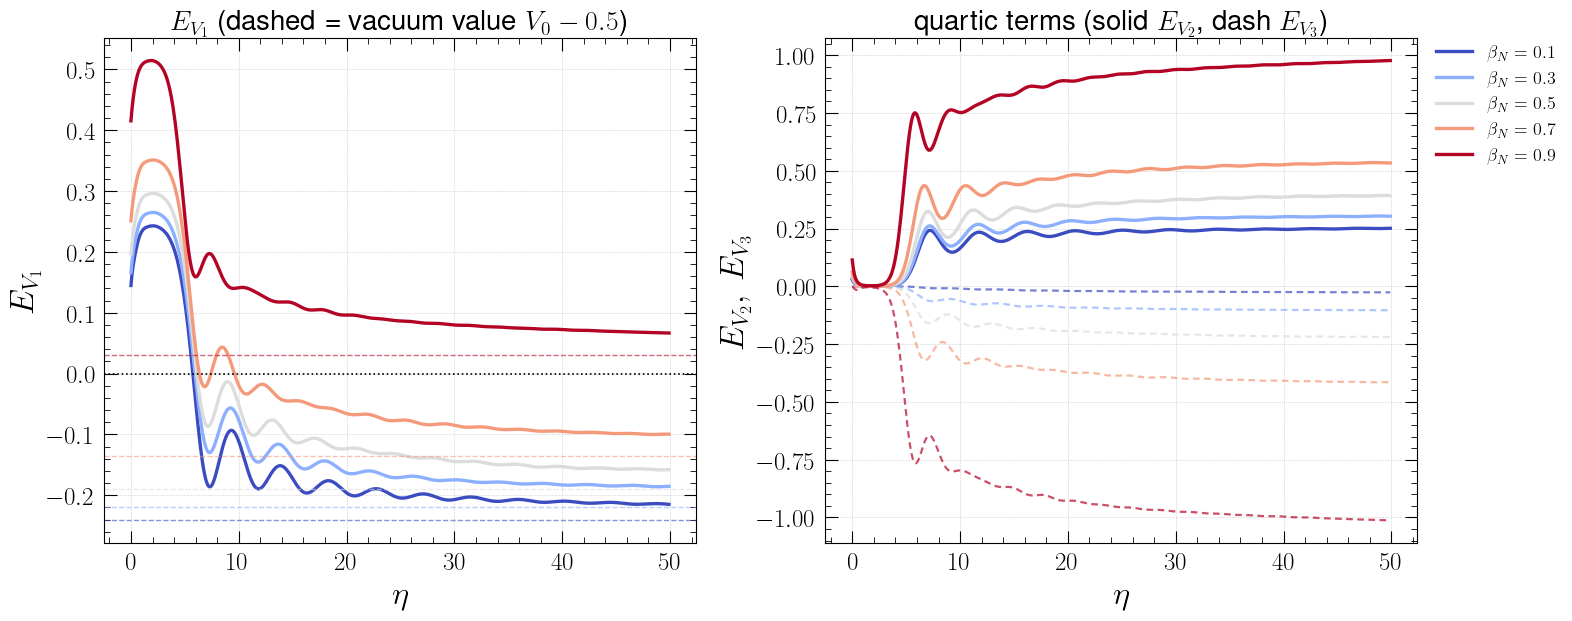

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for d in ready:
    en  = d['energies']
    vac = d['V0'] - 0.5   # vacuum value of Ev_1
    axes[0].plot(en['eta'], en['Ev_1'], color=d['color'], ls=d['ls'], lw=d['lw'])
    axes[0].axhline(vac, color=d['color'], ls='--', lw=1.0, alpha=0.6)
    axes[1].plot(en['eta'], en['Ev_2'], color=d['color'], ls=d['ls'], lw=d['lw'],
                 label=d['label'])
    axes[1].plot(en['eta'], en['Ev_3'], color=d['color'], ls=(0,(3,2)), lw=1.6,
                 alpha=0.7)

axes[0].axhline(0, color='k', ls=':', lw=1.2)

paper_ax(axes[0], ylabel=r'$E_{V_1}$',
         title=r'$E_{V_1}$ (dashed = vacuum value $V_0-0.5$)')
paper_ax(axes[1], ylabel=r'$E_{V_2},\;E_{V_3}$',
         title=r'quartic terms (solid $E_{V_2}$, dash $E_{V_3}$)')
add_legend(axes[1], ready)
plt.tight_layout()
plt.show()

## 3. Wall-area parameter $\mathcal{A}_1$

$\mathcal{A}_1 \equiv \mathrm{scal}_1/(2aH)$; since $2aH=2$ exactly in this run,
$\mathcal{A}_1 = \mathrm{scal}_1/2$.  A plateau indicates scaling
($\mathcal{A}_1 \sim \mathcal{O}(1)$ is the expected scaling value).

**Left panel:** linear axes.  **Right panel:** log--log (eye-guide for power-law / plateau).

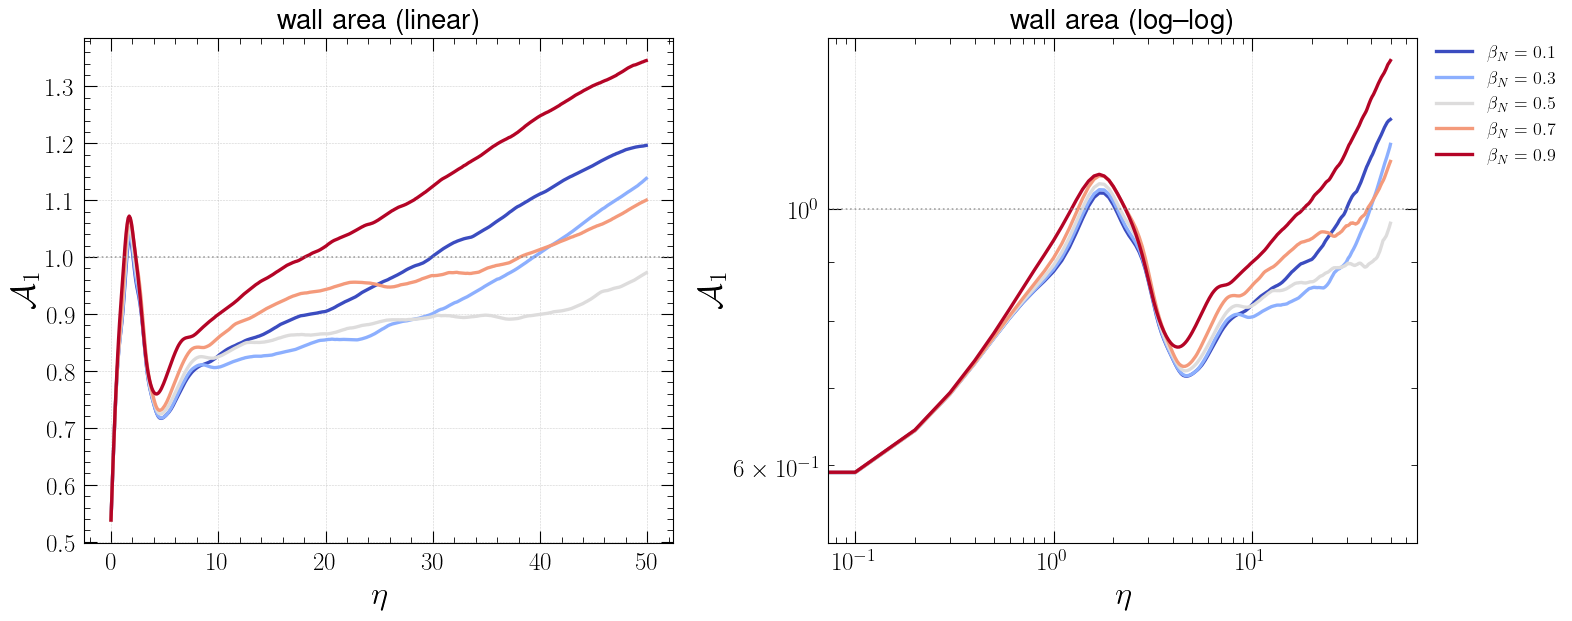

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for d in ready:
    eta, A1 = area_param_A1(d)
    axes[0].plot(eta, A1, color=d['color'], ls=d['ls'], lw=d['lw'])
    axes[1].plot(eta, A1, color=d['color'], ls=d['ls'], lw=d['lw'])

for ax in axes:
    ax.axhline(1.0, color='gray', ls=':', lw=1.2, alpha=0.7)

axes[1].set_xscale('log')
axes[1].set_yscale('log')

paper_ax(axes[0], ylabel=r'$\mathcal{A}_1$', title=r'wall area (linear)')
paper_ax(axes[1], ylabel=r'$\mathcal{A}_1$', title=r'wall area (log--log)')
add_legend(axes[1], ready)
plt.tight_layout()
plt.show()

## 4. Local logarithmic slope ${\rm d}\ln\mathcal{A}_1/{\rm d}\ln\eta$

Scaling $\Leftrightarrow$ slope $\to 0$.  Shown only for $\eta > 5$
(avoid early transient).  A slope of $0$ would indicate perfect scaling;
a positive slope means still growing; a negative slope means decaying.

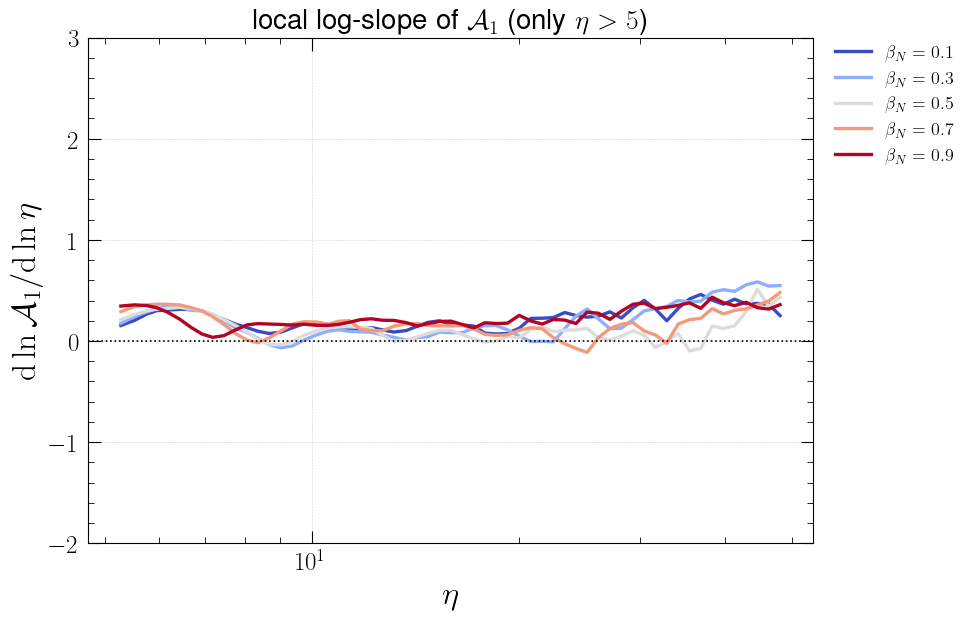

In [9]:
fig, ax = plt.subplots(figsize=(10, 6.5))
for d in ready:
    eta, A1 = area_param_A1(d)
    sel = eta > 5.0
    xs, sl = local_logslope(eta[sel], A1[sel])
    if xs.size > 0:
        ax.plot(xs, sl, color=d['color'], ls=d['ls'], lw=d['lw'])

ax.axhline(0, color='k', ls=':', lw=1.2)
ax.set_xscale('log')
ax.set_ylim(-2, 3)
paper_ax(ax, ylabel=r'${\rm d}\ln\mathcal{A}_1/{\rm d}\ln\eta$',
         title=r'local log-slope of $\mathcal{A}_1$ (only $\eta>5$)')
add_legend(ax, ready)
plt.tight_layout()
plt.show()

## 5. Logarithmic-drift fit $\mathcal{A}_1 = c_1 + c_2\ln\eta$ over $\eta\in[15,50]$

If $\mathcal{A}_1$ has not fully plateaued, a log-drift fit quantifies the residual
growth.  We compare $c_2(\beta_N)$ to the Z4 long-scan reference values to see
whether the string-limit trend ($c_2$ rising as $\beta_N\to 0$, i.e.\ as walls
become broader and string-like) also holds in Z3.

card         bN        c1        c2       rms
--------------------------------------------
b30p1       0.1    0.0240    0.2942   0.02002
b30p3       0.3    0.0670    0.2568   0.03224
b30p5       0.5    0.6555    0.0704   0.01241
b30p7       0.7    0.5439    0.1294   0.01984
b30p9       0.9    0.0149    0.3333   0.01981



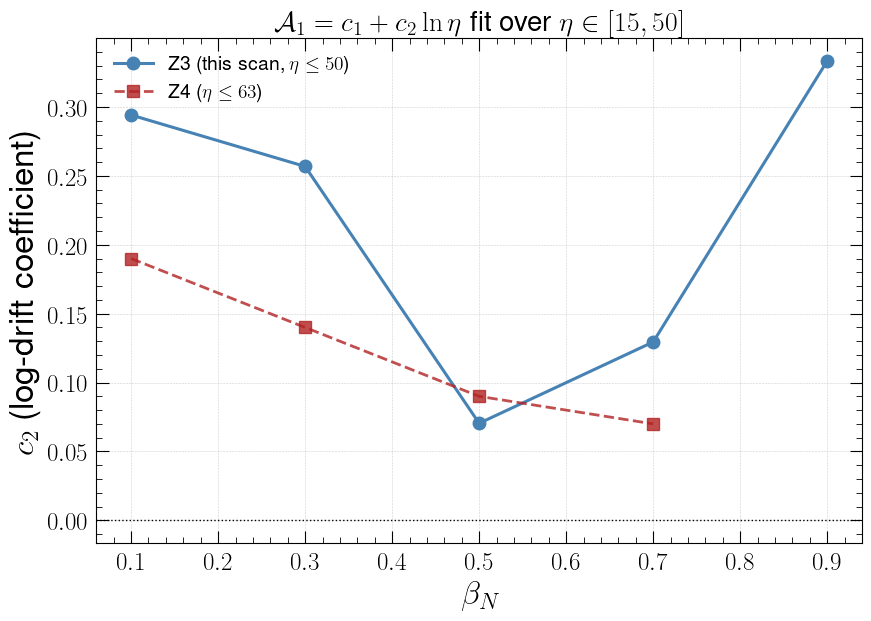

In [10]:
FIT_ETA_MIN = 15.0
FIT_ETA_MAX = 50.0

# Z4 long-scan (eta<=63) reference values from previous analysis
Z4_REF = {0.1: 0.19, 0.3: 0.14, 0.5: 0.09, 0.7: 0.07}

fit_results = {}
print(f"{'card':10s} {'bN':>4s} {'c1':>9s} {'c2':>9s} {'rms':>9s}")
print('-' * 44)
for d in ready:
    eta, A1 = area_param_A1(d)
    sel = (eta >= FIT_ETA_MIN) & (eta <= FIT_ETA_MAX)
    if sel.sum() < 5:
        print(f"{d['name']:10s} {d['beta_N']:>4.1f}  insufficient data")
        continue
    ln_eta = np.log(eta[sel])
    A1_fit = A1[sel]
    X = np.column_stack([np.ones_like(ln_eta), ln_eta])
    coeffs, res, _, _ = np.linalg.lstsq(X, A1_fit, rcond=None)
    c1, c2 = coeffs
    rms = float(np.sqrt(np.mean((A1_fit - X @ coeffs)**2)))
    fit_results[d['beta_N']] = dict(c1=c1, c2=c2, rms=rms)
    print(f"{d['name']:10s} {d['beta_N']:>4.1f} {c1:>9.4f} {c2:>9.4f} {rms:>9.5f}")

print()

# Plot c2 vs beta_N: Z3 results + Z4 reference
fig, ax = plt.subplots(figsize=(9, 6.5))

bN_z3  = sorted(fit_results.keys())
c2_z3  = [fit_results[b]['c2'] for b in bN_z3]
ax.plot(bN_z3, c2_z3, 'o-', color='steelblue', lw=2.2, ms=9,
        label=r'Z3 (this scan, $\eta\le50$)')

bN_z4  = sorted(Z4_REF.keys())
c2_z4  = [Z4_REF[b] for b in bN_z4]
ax.plot(bN_z4, c2_z4, 's--', color='firebrick', lw=2.0, ms=8, alpha=0.8,
        label=r'Z4 ($\eta\le63$)')

ax.axhline(0, color='k', ls=':', lw=1.0)
paper_ax(ax, xlabel=r'$\beta_N$',
         ylabel=r'$c_2$ (log-drift coefficient)',
         title=r'$\mathcal{A}_1 = c_1 + c_2\ln\eta$ fit over $\eta\in[15,50]$')
ax.legend(fontsize=14, frameon=False)
plt.tight_layout()
plt.show()

## 6. Kinetic and gradient energies

Both scalar-field components shown together.

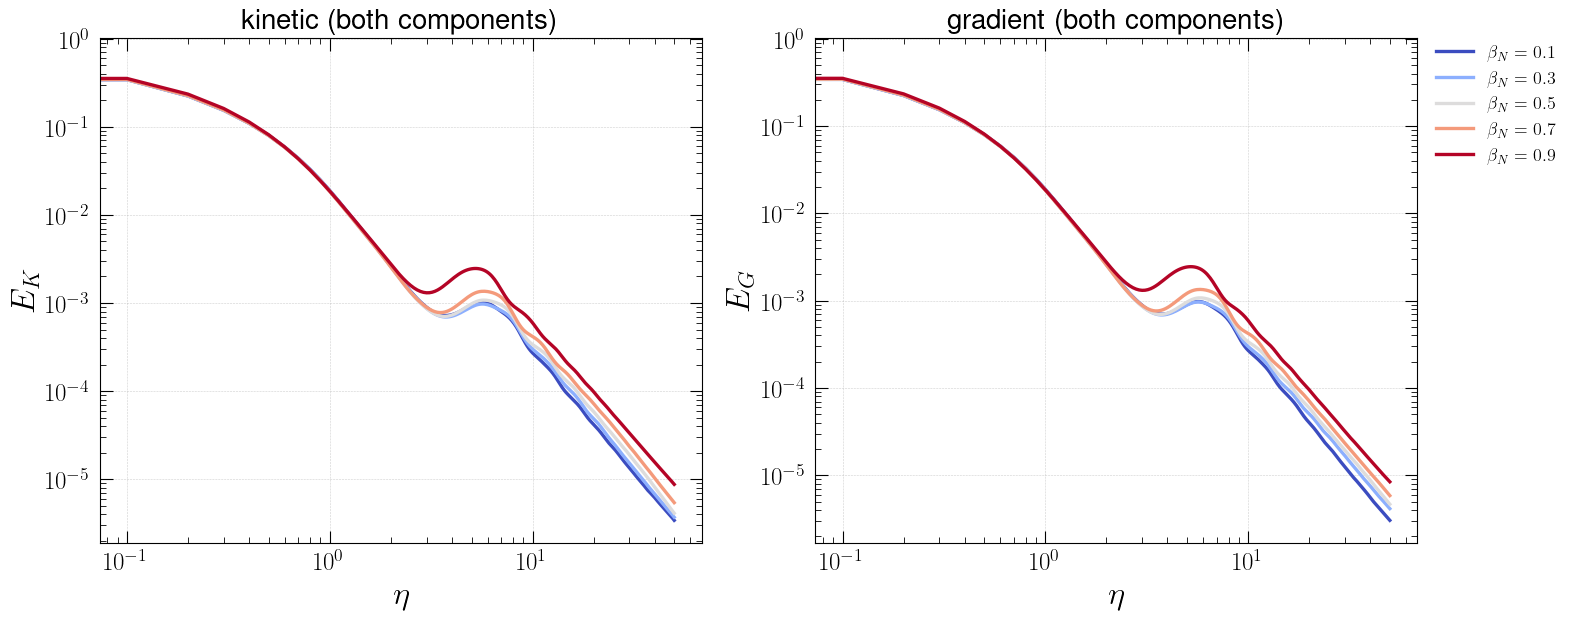

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for d in ready:
    en = d['energies']
    axes[0].plot(en['eta'], en['Ek_1'] + en['Ek_2'],
                 color=d['color'], ls=d['ls'], lw=d['lw'])
    axes[1].plot(en['eta'], en['Eg_1'] + en['Eg_2'],
                 color=d['color'], ls=d['ls'], lw=d['lw'])

for ax in axes:
    ax.set_xscale('log')
    ax.set_yscale('log')

paper_ax(axes[0], ylabel=r'$E_K$', title=r'kinetic (both components)')
paper_ax(axes[1], ylabel=r'$E_G$', title=r'gradient (both components)')
add_legend(axes[1], ready)
plt.tight_layout()
plt.show()

## 7. Scalar field means $\langle\phi\rangle\pm\sigma$ (per component)

Shaded band is $\pm\sigma = \pm\sqrt{\langle\phi^2\rangle - \langle\phi\rangle^2}$.
A mean drifting toward $\pm 1$ (in $h$) or $\pm 1/\sqrt{2}$ (in $a$) with
shrinking $\sigma$ signals finite-volume domain depletion.

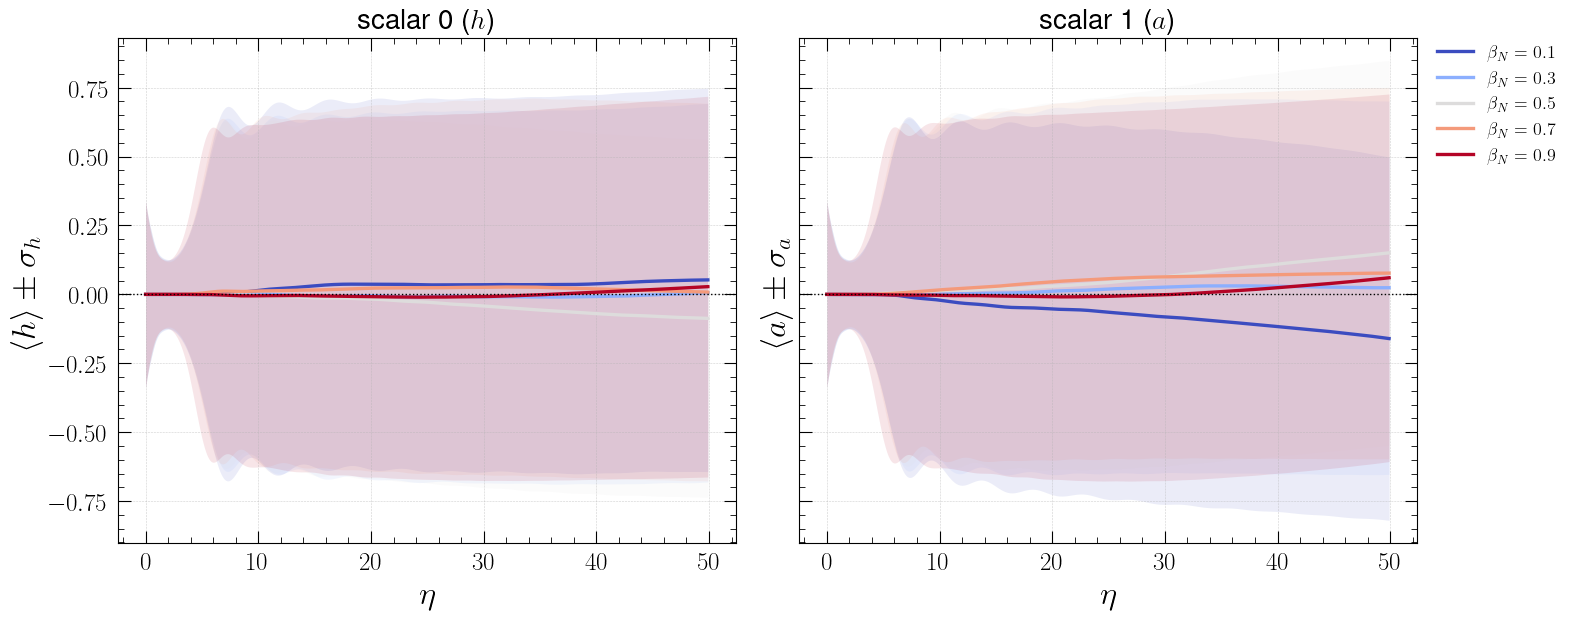

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True, sharey=True)
for d in ready:
    for ax, key in zip(axes, ['scalar_0', 'scalar_1']):
        s = d[key]
        ax.plot(s['eta'], s['phi'], color=d['color'], ls=d['ls'], lw=d['lw'])
        ax.fill_between(s['eta'],
                        s['phi'] - s['rms_phi'],
                        s['phi'] + s['rms_phi'],
                        color=d['color'], alpha=0.10, lw=0)

for ax in axes:
    ax.axhline(0, color='k', ls=':', lw=1.0)

paper_ax(axes[0], ylabel=r'$\langle h\rangle \pm \sigma_h$', title=r'scalar 0 ($h$)')
paper_ax(axes[1], ylabel=r'$\langle a\rangle \pm \sigma_a$', title=r'scalar 1 ($a$)')
add_legend(axes[1], ready)
plt.tight_layout()
plt.show()

## 8. Summary table

In [13]:
print(f"{'card':10s} {'bN':>4s} {'eta_break':>9s} {'phi2_end':>10s}"
      f" {'drift_end':>10s} {'A1_end':>8s} {'c2':>8s}")
print('-' * 65)
for d in ready:
    eta_brk = breaking_onset_eta(d)
    eta, p2 = phi2_radial(d)
    s0, s1  = d['scalar_0'], d['scalar_1']
    drift   = float(np.sqrt(s0['phi'][-1]**2
                            + np.interp(s0['eta'][-1], s1['eta'], s1['phi'])**2))
    _, A1   = area_param_A1(d)
    A1_e    = float(A1[-1])
    c2_val  = fit_results.get(d['beta_N'], {}).get('c2', float('nan'))
    eb_s    = f'{eta_brk:9.2f}' if eta_brk is not None else '      n/a'
    c2_s    = f'{c2_val:8.4f}' if not np.isnan(c2_val) else '     n/a'
    print(f"{d['name']:10s} {d['beta_N']:>4.1f} {eb_s}"
          f" {p2[-1]:>10.4f} {drift:>10.4f} {A1_e:>8.4f} {c2_s}")

card         bN eta_break   phi2_end  drift_end   A1_end       c2
-----------------------------------------------------------------
b30p1       0.1      5.70     0.4737     0.1688   1.1963   0.2942
b30p3       0.3      5.80     0.4655     0.0248   1.1382   0.2568
b30p5       0.5      5.80     0.4689     0.1741   0.9724   0.0704
b30p7       0.7      5.60     0.4646     0.0775   1.1001   0.1294
b30p9       0.9      4.90     0.4631     0.0665   1.3453   0.3333
